In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.pipeline import  Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression

In [33]:
x,y=make_regression(n_samples=200,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=2)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.686e+04, tolerance: 3.765e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers i

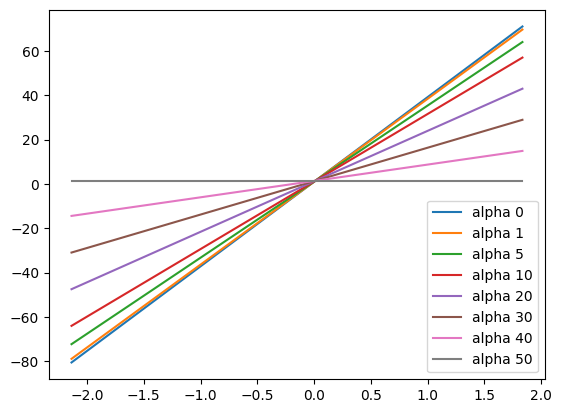

In [34]:
alphas=[0,1,5,10,20,30,40,50]
for i in alphas:
    m=Lasso(alpha=i)
    m.fit(x_train,y_train)
    sns.lineplot(x=x_test.flatten(),y=m.predict(x_test).flatten(),label='alpha {}'.format(i))
plt.legend()
plt.show()

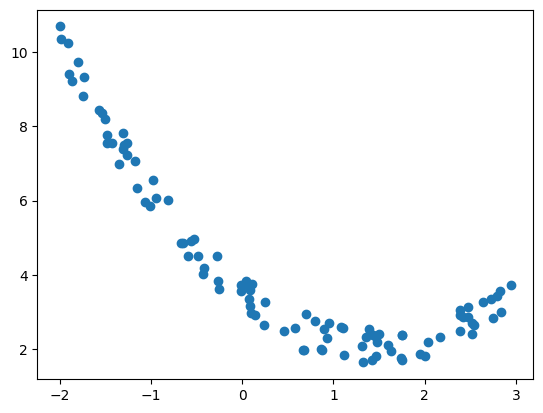

In [71]:
np.random.seed(1)
x=5*np.random.rand(100,1)-2
y=0.7*x**2-2*x+3+np.random.rand(100,1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
plt.scatter(x,y)
plt.show()

C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.955e+00, tolerance: 4.516e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers i

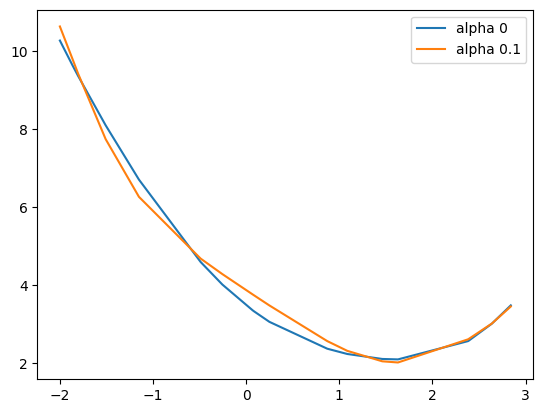

In [76]:
alphas=[0,0.1]

def pred(x1,y1,x2,alpha):
    m=Pipeline([
        ('poly_feats',PolynomialFeatures(degree=20)),
        ('lasso',Lasso(alpha=i))
    ])
    m.fit(x1,y1)
    return m.predict(x2)
    
for i in alphas:
    sns.lineplot(x=x_test.flatten(),y=pred(x_train,y_train,x_test,i).flatten(),label='alpha {}'.format(i))
plt.legend()
plt.show()